# Explainable AI (XAI) for Medical Images 

In this notebook we train a small CNN on **coloured skin-lesion images** and then ask:

> *"Which pixels made the model choose this disease?"*

We will learn 7 XAI methods, one at a time:

| # | Method | Idea in one line |
|---|--------|------------------|
| 1 | **Saliency Map** | Gradient of the class score w.r.t. each pixel |
| 2 | **Guided Backpropagation** | Saliency, but only positive gradients flow back |
| 3 | **CAM** | Weighted sum of the last feature maps using FC weights |
| 4 | **Grad-CAM** | Like CAM, but weights come from gradients |
| 5 | **Grad-CAM++** | Better Grad-CAM weights (good for many / small regions) |
| 6 | **LIME** | Hide image patches, fit a simple model to see which patches matter |
| 7 | **SHAP** | Game theory: fair share of the prediction for each pixel |

**Dataset:** [DermaMNIST](https://medmnist.com/) (from HAM10000) — RGB dermatoscope images, 7 skin-disease classes.

> Tip: Run this notebook in **Google Colab** with a **GPU** (Runtime → Change runtime type → GPU).

## Step 0: Install and import libraries

In [1]:
!pip install -q medmnist lime shap

In [35]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import medmnist
from medmnist import INFO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1: Load a coloured medical image dataset

**DermaMNIST** classes:

0. Actinic keratoses  
1. Basal cell carcinoma  
2. Benign keratosis  
3. Dermatofibroma  
4. **Melanoma**  
5. Melanocytic nevi  
6. Vascular lesions  

We use **128 × 128** colour images.

In [36]:
IMG_SIZE = 128
info = INFO["dermamnist"]
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]
num_classes = len(class_names)

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet stats
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(MEAN, STD)])

DataClass = getattr(medmnist, info["python_class"])
train_ds = DataClass(split="train", transform=transform, download=True, size=IMG_SIZE)
test_ds  = DataClass(split="test",  transform=transform, download=True, size=IMG_SIZE)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=64)
print(len(train_ds), "train images |", len(test_ds), "test images")

7007 train images | 2005 test images


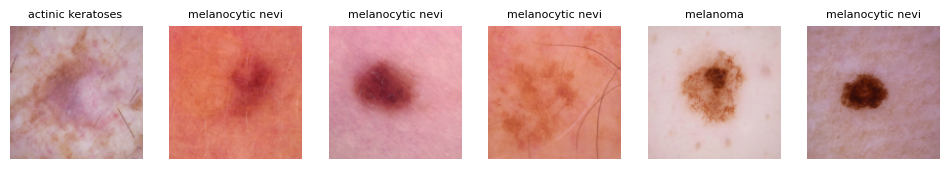

In [37]:
# Helper: convert a normalised tensor (3,H,W) back to a viewable image (H,W,3) in [0,1]
def to_image(t):
    img = t.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

# Show some sample images
plt.figure(figsize=(12, 3))
for i in range(6):
    x, y = train_ds[i]
    plt.subplot(1, 6, i + 1)
    plt.imshow(to_image(x)); plt.title(class_names[int(y[0])][:18], fontsize=8); plt.axis("off")
plt.show()

## Step 2: Train a simple CNN (ResNet-18)

We use a **pre-trained ResNet-18** and replace its last layer with 7 outputs.

ResNet-18 ends with: `layer4 (feature maps) → Global Average Pooling → fc (Linear)`.  
This structure is exactly what **CAM** needs.

In [38]:
model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.squeeze(1).long().to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: last batch loss = {loss.item():.3f}")

Epoch 1: last batch loss = 0.413
Epoch 2: last batch loss = 0.435
Epoch 3: last batch loss = 0.431


In [39]:
# Test accuracy
model.eval()
correct = total = 0
with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(device)).argmax(1).cpu()
        correct += (pred == y.squeeze(1)).sum().item()
        total += len(y)
print(f"Test accuracy: {100*correct/total:.1f}%")

Test accuracy: 74.9%


## Step 3: Pick one test image to explain

We choose a **melanoma** image (class 4) and see what the model predicts.

True label     : melanoma
Predicted label: benign keratosis-like lesions (0.51)


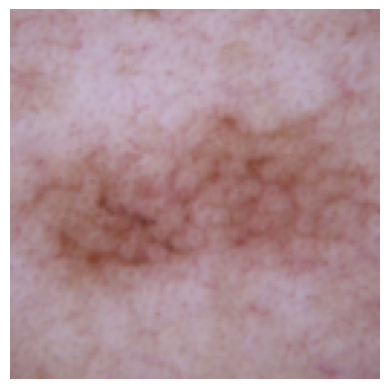

In [40]:
labels = test_ds.labels.squeeze()
idx = int(np.where(labels == 4)[0][0])        # first melanoma image
x, y = test_ds[idx]
x = x.unsqueeze(0).to(device)                 # shape (1, 3, H, W)
image = to_image(x[0])                        # for plotting

with torch.no_grad():
    probs = F.softmax(model(x), dim=1)[0]
pred_class = int(probs.argmax())

print("True label     :", class_names[int(y[0])])
print("Predicted label:", class_names[pred_class], f"({probs[pred_class].item():.2f})")
plt.imshow(image); plt.axis("off"); plt.show()

In [41]:
# Helper to show image + heatmap side by side
def show(heatmap, title, cmap="jet"):
    plt.figure(figsize=(9, 3))
    plt.subplot(1, 3, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heatmap, cmap=cmap); plt.title(title); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(image); plt.imshow(heatmap, cmap=cmap, alpha=0.5)
    plt.title("Overlay"); plt.axis("off")
    plt.show()

def normalize(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)

---
## 1. Saliency Map (Vanilla Gradients)

**Idea:** If changing a pixel a little changes the class score a lot, that pixel is important.

$$
\text{Saliency}(i,j) = \max_{c \in \{R,G,B\}} \left| \frac{\partial S_{\text{class}}}{\partial x_{c,i,j}} \right|
$$

**Steps**
1. Forward pass the image.
2. Back-propagate the score of the predicted class to the **input image**.
3. Take the absolute gradient and max over the 3 colour channels.

✅ Simple and fast ❌ Noisy, looks like "static"

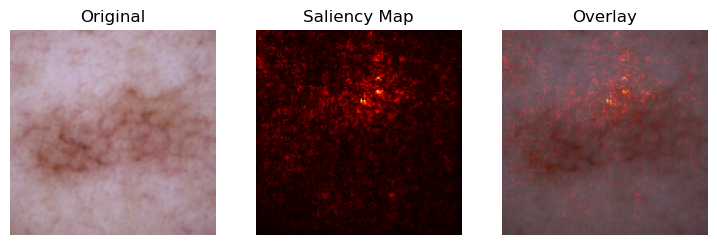

In [42]:
x_in = x.clone().requires_grad_(True)
score = model(x_in)[0, pred_class]
score.backward()

saliency = x_in.grad[0].abs().max(dim=0)[0].cpu().numpy()
show(normalize(saliency), "Saliency Map", cmap="hot")

# Saliency Map = WHERE is important?
# Overlay = WHERE is important + WHERE is it on the original image?


---
## 2. Guided Backpropagation

**Idea:** Same as saliency, but at every **ReLU** we only let **positive** gradients go back.

At each ReLU during the backward pass:

$$
R^{(l)} = \underbrace{(f^{(l)} > 0)}_{\text{normal ReLU rule}} \cdot \underbrace{(R^{(l+1)} > 0)}_{\text{extra "guided" rule}} \cdot R^{(l+1)}
$$

So only features that **increase** the class score are kept → sharper, cleaner edges.

✅ Very sharp, fine details ❌ Not class-discriminative (looks similar for every class)

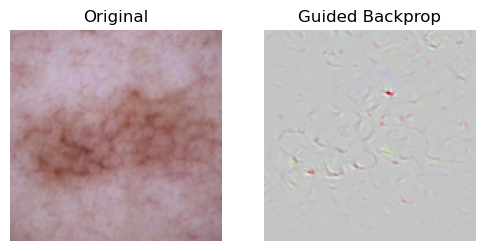

In [44]:
gb_model = copy.deepcopy(model).eval()

# Clamp negative gradients at every ReLU
def guided_relu_hook(module, grad_in, grad_out):
    return (torch.clamp(grad_in[0], min=0.0),)

for m in gb_model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False
        m.register_full_backward_hook(guided_relu_hook)

x_in = x.clone().requires_grad_(True)
gb_model(x_in)[0, pred_class].backward()

guided_grads = x_in.grad[0].cpu().numpy().transpose(1, 2, 0)   # (H, W, 3)
guided_img = normalize(guided_grads)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(guided_img); plt.title("Guided Backprop"); plt.axis("off")
plt.show()

---
## 3. CAM (Class Activation Mapping)

**Idea:** The last conv layer gives $K$ feature maps $A^k$. The final `fc` layer has one weight $w_k^c$ per map for class $c$.

$$
\text{CAM}^c = \sum_k w_k^c \, A^k
$$

Then upsample the small map (4×4 here) to image size.

**Requirement:** the network must end with `Conv → Global Average Pooling → FC` (ResNet does ✅).

✅ Class-specific, no gradients needed ❌ Works only for this special architecture

In [45]:
# Save the output of the last conv block (layer4) with a forward hook
store = {}
def forward_hook(module, inp, out):
    store["act"] = out                                  # (1, 512, h, w)
    if out.requires_grad:                               # also save its gradient
        out.register_hook(lambda g: store.update(grad=g))

hook = model.layer4.register_forward_hook(forward_hook)

def upsample(cam):
    cam = F.interpolate(cam[None, None], size=(IMG_SIZE, IMG_SIZE), mode="bilinear")
    return normalize(cam[0, 0].detach().cpu().numpy())

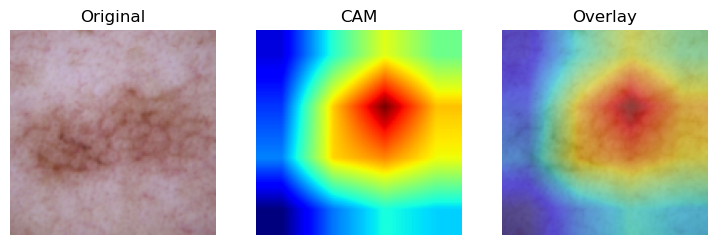

In [46]:
with torch.no_grad():
    model(x)
A = store["act"][0]                        # (512, h, w)
w = model.fc.weight[pred_class]            # (512,)

cam = F.relu((w[:, None, None] * A).sum(0))
cam_map = upsample(cam)
show(cam_map, "CAM")

<img src="https://i.postimg.cc/zB5pyV7R/1-(2).png" width="600">

---
## 4. Grad-CAM (Gradient-weighted CAM)

**Idea:** Replace CAM's FC weights by the **average gradient** of each feature map. Works for **any** CNN.

$$
\alpha_k^c = \frac{1}{Z}\sum_{i}\sum_{j} \frac{\partial y^c}{\partial A^k_{ij}}
\qquad\qquad
\text{Grad-CAM}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)
$$

- $\alpha_k^c$ = how important feature map $k$ is for class $c$
- ReLU keeps only regions that **support** the class

✅ Any CNN, class-specific ❌ Coarse (low resolution); may miss multiple objects

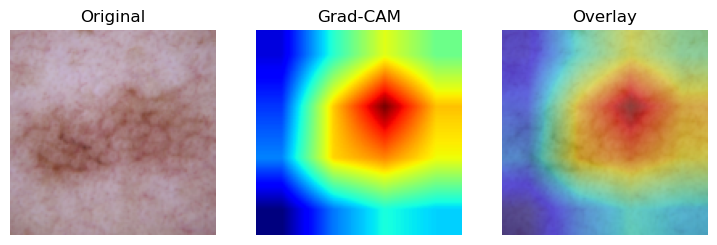

In [48]:
model.zero_grad()
score = model(x)[0, pred_class]
score.backward()

A = store["act"][0]           # (512, h, w)
G = store["grad"][0]          # (512, h, w)

alpha = G.mean(dim=(1, 2))                          # average gradient per map
gradcam = F.relu((alpha[:, None, None] * A).sum(0))
gradcam_map = upsample(gradcam)
show(gradcam_map, "Grad-CAM")

---
## 5. Grad-CAM++

**Idea:** Grad-CAM gives every pixel of a map the *same* weight. Grad-CAM++ uses **pixel-wise weights** $a_{ij}^{kc}$ built from 2nd- and 3rd-order gradients, so **several or small lesion regions** are highlighted better.

$$
a_{ij}^{kc} = \frac{g_{ij}^2}{2\,g_{ij}^2 + \sum_{a,b} A^k_{ab}\; g_{ij}^3}
\qquad
w_k^c = \sum_{i,j} a_{ij}^{kc}\;\text{ReLU}(g_{ij})
$$

$$
\text{Grad-CAM++}^c = \text{ReLU}\left(\sum_k w_k^c A^k\right)
\qquad \text{where } g = \frac{\partial y^c}{\partial A^k}
$$

✅ Better localisation of multiple/small regions ❌ Slightly more maths

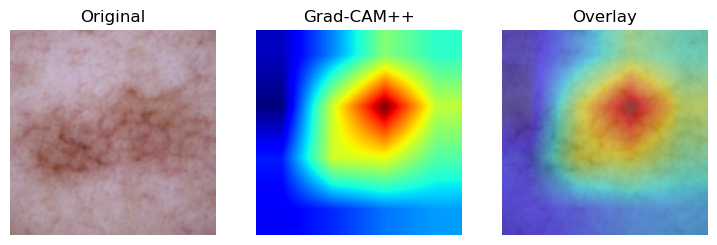

In [49]:
# A and G are still stored from the Grad-CAM step
g2, g3 = G ** 2, G ** 3
sum_A = A.sum(dim=(1, 2), keepdim=True)

a = g2 / (2 * g2 + sum_A * g3 + 1e-8)
weights = (a * F.relu(G)).sum(dim=(1, 2))

gradcampp = F.relu((weights[:, None, None] * A).sum(0))
gradcampp_map = upsample(gradcampp)
show(gradcampp_map, "Grad-CAM++")

hook.remove()   # we don't need the hook anymore

---
## 6. LIME (Local Interpretable Model-agnostic Explanations)

**Idea:** Treat the model as a **black box**.

1. Split the image into **superpixels** (small patches).
2. Create many copies of the image with random patches **hidden** (greyed out).
3. Ask the model to predict each copy.
4. Fit a simple **linear model**: *"which patches, when present, increase the score?"*

$$
\xi(x) = \arg\min_{g} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)
$$

($f$ = our CNN, $g$ = simple linear model, $\pi_x$ = closeness to original image, $\Omega$ = keep it simple)

✅ Model-agnostic, easy to understand ❌ Slow, results change with random sampling

  0%|          | 0/1000 [00:00<?, ?it/s]

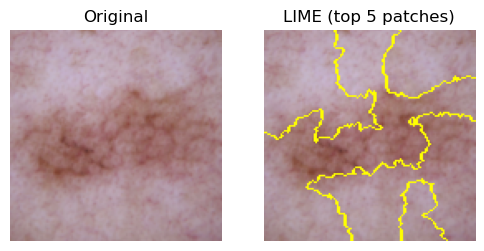

In [64]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

# LIME gives us numpy images (N, H, W, 3) in [0,1]; we return class probabilities
def predict_fn(images):
    batch = torch.stack([transform(img.astype(np.float32)) for img in images]).to(device)
    with torch.no_grad():
        return F.softmax(model(batch), dim=1).cpu().numpy()

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image.astype(np.double), predict_fn,
                                         top_labels=1, num_samples=1000)

temp, mask = explanation.get_image_and_mask(pred_class, positive_only=True,
                                            num_features=10, hide_rest=False)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(mark_boundaries(temp, mask)); plt.title("LIME (top 5 patches)"); plt.axis("off")
plt.show()
lime_map = mask.astype(float)

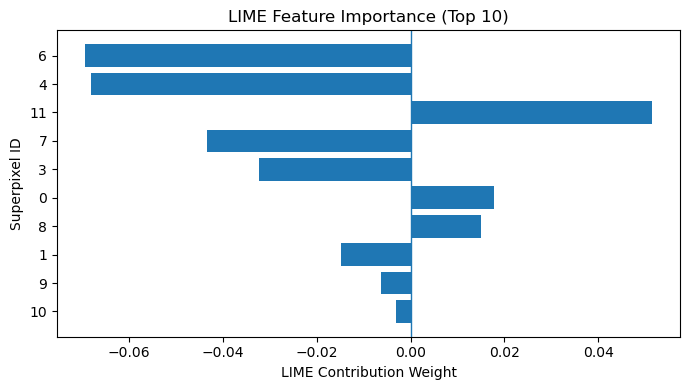

In [61]:
# ---------------------------------------------------------
# Third plot: LIME feature importance
# ---------------------------------------------------------

# Get the local explanation for the predicted class
lime_weights = explanation.local_exp[pred_class]

# Sort features by absolute contribution
lime_weights_sorted = sorted(
    lime_weights,
    key=lambda x: abs(x[1]),
    reverse=True
)[:10]

feature_ids = [str(x[0]) for x in lime_weights_sorted]
weights = [x[1] for x in lime_weights_sorted]

plt.figure(figsize=(7, 4))

plt.barh(
    feature_ids[::-1],
    weights[::-1]
)

plt.axvline(0, linewidth=1)

plt.xlabel("LIME Contribution Weight")
plt.ylabel("Superpixel ID")
plt.title("LIME Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

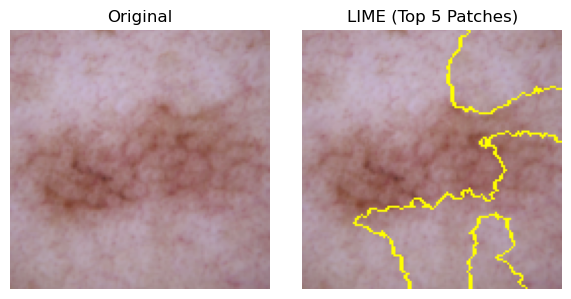

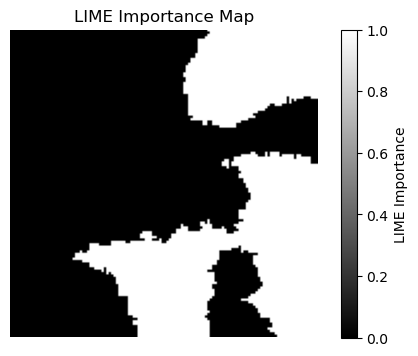

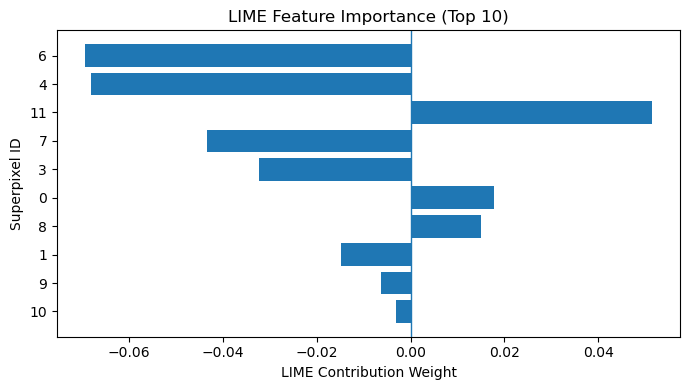

In [62]:
# ---------------------------------------------------------
# 1. Original + LIME explanation
# ---------------------------------------------------------

temp, mask = explanation.get_image_and_mask(
    pred_class,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME (Top 5 Patches)")
plt.axis("off")

plt.tight_layout()
plt.show()

lime_map = mask.astype(float)


# ---------------------------------------------------------
# 2. LIME importance map
# ---------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.imshow(lime_map, cmap="gray")
plt.colorbar(label="LIME Importance")
plt.title("LIME Importance Map")
plt.axis("off")
plt.show()


# ---------------------------------------------------------
# 3. LIME feature contribution
# ---------------------------------------------------------

lime_weights = explanation.local_exp[pred_class]

lime_weights_sorted = sorted(
    lime_weights,
    key=lambda x: abs(x[1]),
    reverse=True
)[:10]

feature_ids = [str(x[0]) for x in lime_weights_sorted]
weights = [x[1] for x in lime_weights_sorted]

plt.figure(figsize=(7, 4))

plt.barh(
    feature_ids[::-1],
    weights[::-1]
)

plt.axvline(0, linewidth=1)

plt.xlabel("LIME Contribution Weight")
plt.ylabel("Superpixel ID")
plt.title("LIME Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

---
## 7. SHAP (SHapley Additive exPlanations)

**Idea:** From game theory. Each pixel is a "player"; the prediction is the "prize". The **Shapley value** $\phi_i$ is the fair share of pixel $i$:

$$
\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(|N|-|S|-1)!}{|N|!}\Big[f(S \cup \{i\}) - f(S)\Big]
$$

And they add up to the prediction:  $f(x) = \phi_0 + \sum_i \phi_i$

We use `shap.GradientExplainer` (fast approximation for deep nets) with some training images as the **background**.

- 🔴 **Red** = pixel pushes prediction **towards** the class
- 🔵 **Blue** = pixel pushes prediction **away** from the class

✅ Strong theory, shows positive & negative evidence ❌ Slow, needs a background set

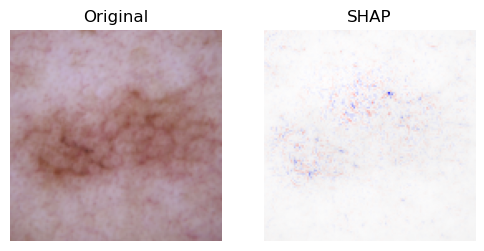

In [51]:
import shap

background = torch.stack([train_ds[i][0] for i in range(50)]).to(device)
shap_explainer = shap.GradientExplainer(model, background)
sv = np.array(shap_explainer.shap_values(x))

# Different SHAP versions return different shapes -> pick the predicted class
if sv.shape[-1] == num_classes:      # (1, 3, H, W, classes)
    sv_class = sv[0, ..., pred_class]
else:                                # (classes, 1, 3, H, W)
    sv_class = sv[pred_class, 0]

shap_map = sv_class.sum(axis=0)      # add up R, G, B  -> (H, W)
lim = np.abs(shap_map).max()

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(image.mean(2), cmap="gray", alpha=0.4)
plt.imshow(shap_map, cmap="bwr", vmin=-lim, vmax=lim, alpha=0.8); plt.title("SHAP"); plt.axis("off")
plt.show()

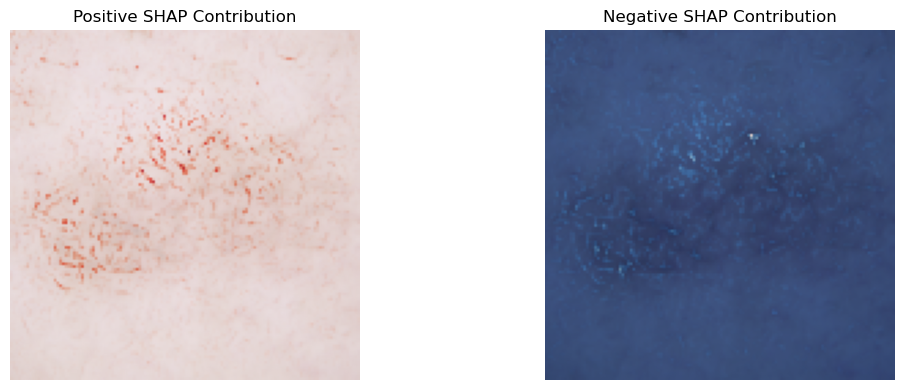

In [52]:
# ---------------------------------------------------------
# 2. Positive and Negative SHAP Contributions
# ---------------------------------------------------------

positive_shap = np.maximum(shap_map, 0)
negative_shap = np.minimum(shap_map, 0)

lim_pos = positive_shap.max()
lim_neg = np.abs(negative_shap).max()

plt.figure(figsize=(12, 4))

# Positive contribution
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.imshow(
    positive_shap,
    cmap="Reds",
    alpha=0.7,
    vmin=0,
    vmax=lim_pos
)
plt.title("Positive SHAP Contribution")
plt.axis("off")

# Negative contribution
plt.subplot(1, 2, 2)
plt.imshow(image)
plt.imshow(
    negative_shap,
    cmap="Blues",
    alpha=0.7,
    vmin=-lim_neg,
    vmax=0
)
plt.title("Negative SHAP Contribution")
plt.axis("off")

plt.tight_layout()
plt.show()

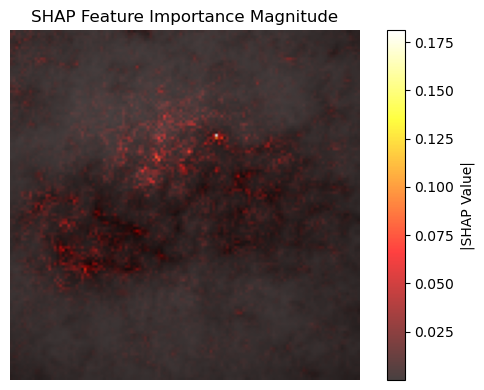

In [53]:
# ---------------------------------------------------------
# 3. SHAP Magnitude Map
# ---------------------------------------------------------

shap_magnitude = np.abs(shap_map)

plt.figure(figsize=(6, 4))

plt.imshow(image.mean(axis=2), cmap="gray")
plt.imshow(
    shap_magnitude,
    cmap="hot",
    alpha=0.75
)

plt.colorbar(label="|SHAP Value|")
plt.title("SHAP Feature Importance Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

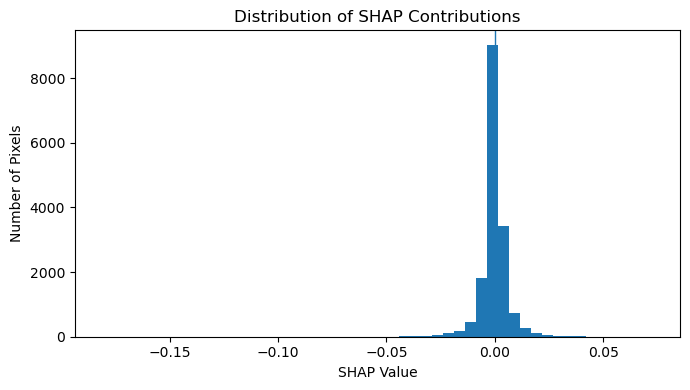

In [54]:
# ---------------------------------------------------------
# 4. SHAP Contribution Distribution
# ---------------------------------------------------------

shap_values_flat = shap_map.flatten()

plt.figure(figsize=(7, 4))

plt.hist(
    shap_values_flat,
    bins=50
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Number of Pixels")
plt.title("Distribution of SHAP Contributions")

plt.tight_layout()
plt.show()

---
## Step 4: Compare all methods side by side

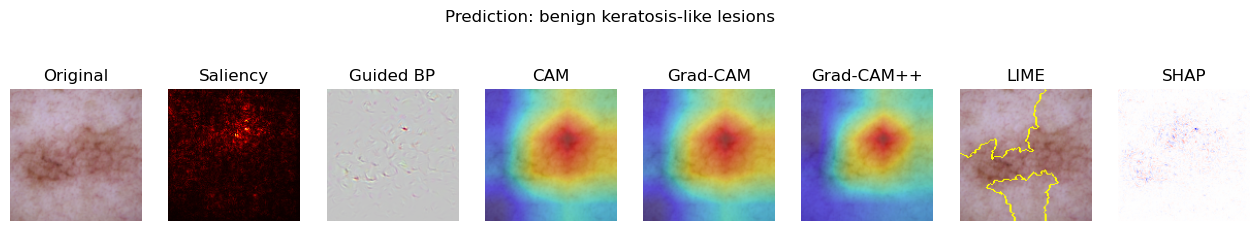

In [55]:
results = {
    "Saliency": (normalize(saliency), "hot"),
    "Guided BP": (guided_img, None),
    "CAM": (cam_map, "jet"),
    "Grad-CAM": (gradcam_map, "jet"),
    "Grad-CAM++": (gradcampp_map, "jet"),
    "LIME": (mark_boundaries(temp, mask), None),
    "SHAP": (shap_map, "bwr"),
}

plt.figure(figsize=(16, 3))
plt.subplot(1, 8, 1); plt.imshow(image); plt.title("Original"); plt.axis("off")
for i, (name, (m, cmap)) in enumerate(results.items()):
    plt.subplot(1, 8, i + 2)
    if name in ["CAM", "Grad-CAM", "Grad-CAM++"]:
        plt.imshow(image); plt.imshow(m, cmap=cmap, alpha=0.5)
    elif name == "SHAP":
        plt.imshow(m, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        plt.imshow(m, cmap=cmap)
    plt.title(name); plt.axis("off")
plt.suptitle(f"Prediction: {class_names[pred_class]}")
plt.show()

---
# Part 2: Quantitative Evaluation of Explanations

Pictures are nice, but **which method is actually better?** We need numbers.

DermaMNIST has **no ground-truth lesion masks**, so we can't measure "did it point at the lesion?".
Instead we measure properties an explanation *should* have:

| Metric | Question it answers | Better |
|---|---|---|
| **Deletion AUC** | If I remove the "important" pixels first, does the score drop fast? | ⬇ Lower |
| **Insertion AUC** | If I add the "important" pixels first, does the score rise fast? | ⬆ Higher |
| **Average Drop %** | If I keep only the highlighted region, how much confidence is lost? | ⬇ Lower |
| **Increase in Confidence %** | How often does the highlighted region alone give *higher* confidence? | ⬆ Higher |
| **Sparsity (Gini)** | Is the map focused on a few pixels, or spread everywhere? | ⬆ Higher |
| **Stability** | Does the map stay the same when tiny noise is added? | ⬆ Higher |
| **Sanity check (randomisation)** | Does the map *change* when the model weights are random? | ⬇ Lower similarity |

The first four measure **faithfulness** (does the map reflect what the model really uses?).
Sparsity measures **understandability**, stability measures **robustness**, and the sanity check tests whether
the method explains the **model** at all (Adebayo et al., 2018).

> Tip: If you have a dataset **with lesion masks** (e.g. ISIC 2018 Task 1), you can also compute
> **IoU** and **Pointing Game** (is the hottest pixel inside the mask?).

## Step 5: Put every method in a function

To test many images we wrap each method as `method(model, x, cls) → heatmap (H×W, values 0–1)`.
It's the same code as above, just packed into functions.

In [31]:
from scipy.stats import spearmanr
import pandas as pd

def to_map(t):
    # tensor or array -> (IMG_SIZE, IMG_SIZE) numpy map in [0, 1]
    t = torch.as_tensor(np.asarray(t.detach().cpu() if torch.is_tensor(t) else t), dtype=torch.float32)
    if t.shape[-1] != IMG_SIZE:
        t = F.interpolate(t[None, None], size=(IMG_SIZE, IMG_SIZE), mode="bilinear")[0, 0]
    return normalize(t.numpy())

def get_A_and_G(m, x, cls):
    # activations and gradients of layer4 for class `cls`
    store = {}
    def fh(module, inp, out):
        store["A"] = out
        out.register_hook(lambda g: store.update(G=g))
    h = m.layer4.register_forward_hook(fh)
    m.zero_grad()
    m(x)[0, cls].backward()
    h.remove()
    return store["A"][0].detach(), store["G"][0].detach()

def saliency_fn(m, x, cls):
    xi = x.clone().requires_grad_(True)
    m(xi)[0, cls].backward()
    return to_map(xi.grad[0].abs().max(0)[0])

def guided_fn(m, x, cls):
    gm = copy.deepcopy(m)
    for mod in gm.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False
            mod.register_full_backward_hook(guided_relu_hook)
    xi = x.clone().requires_grad_(True)
    gm(xi)[0, cls].backward()
    return to_map(xi.grad[0].abs().max(0)[0])

def cam_fn(m, x, cls):
    A, _ = get_A_and_G(m, x, cls)
    w = m.fc.weight[cls].detach()
    return to_map(F.relu((w[:, None, None] * A).sum(0)))

def gradcam_fn(m, x, cls):
    A, G = get_A_and_G(m, x, cls)
    return to_map(F.relu((G.mean((1, 2))[:, None, None] * A).sum(0)))

def gradcampp_fn(m, x, cls):
    A, G = get_A_and_G(m, x, cls)
    a = G**2 / (2 * G**2 + A.sum((1, 2), keepdim=True) * G**3 + 1e-8)
    w = (a * F.relu(G)).sum((1, 2))
    return to_map(F.relu((w[:, None, None] * A).sum(0)))

def lime_fn(m, x, cls):
    def pred(imgs):
        b = torch.stack([transform(i.astype(np.float32)) for i in imgs]).to(device)
        with torch.no_grad():
            return F.softmax(m(b), 1).cpu().numpy()
    exp = lime_image.LimeImageExplainer().explain_instance(
        to_image(x[0]).astype(np.double), pred, labels=(cls,), top_labels=None,
        num_samples=300, batch_size=50, random_seed=0)
    weights = dict(exp.local_exp[cls])                       # superpixel -> weight
    heat = np.vectorize(lambda s: max(weights.get(s, 0), 0))(exp.segments)
    return to_map(heat)

def shap_fn(m, x, cls):
    sv = np.array(shap.GradientExplainer(m, background).shap_values(x, nsamples=100))
    sv = sv[0, ..., cls] if sv.shape[-1] == num_classes else sv[cls, 0]
    return to_map(np.maximum(sv.sum(0), 0))                  # positive evidence only

METHODS = {"Saliency": saliency_fn, "Guided BP": guided_fn, "CAM": cam_fn,
           "Grad-CAM": gradcam_fn, "Grad-CAM++": gradcampp_fn,
           "LIME": lime_fn, "SHAP": shap_fn}

## Step 6: Define the metrics

### Deletion & Insertion AUC
Sort pixels from most to least important.

- **Deletion:** remove pixels step by step (set to the mean colour) and track the class probability.
  A good map makes the curve **fall fast** → small area under curve (AUC).
- **Insertion:** start from a **blurred** image and put the important pixels back first.
  A good map makes the curve **rise fast** → large AUC.

### Average Drop & Increase in Confidence (from the Grad-CAM++ paper)
Keep only the explained region: $x' = x \odot M$. Let $Y$ = original confidence, $O$ = confidence on $x'$.

$$
\text{Avg Drop} = \frac{100}{N}\sum \frac{\max(0,\,Y - O)}{Y}
\qquad
\text{Increase} = \frac{100}{N}\sum \mathbb{1}[O > Y]
$$

### Sparsity (Gini index)
0 = every pixel equally important, 1 = only one pixel important.

### Stability
Spearman correlation between the map of $x$ and of $x + \text{small noise}$ (1 = identical ranking).

### Sanity check
Spearman correlation between the map from the **trained** model and from a **random-weight** model.
If they are similar, the method is showing image edges, **not** what the model learned. ⚠

In [32]:
STEPS = 20

def prob(m, imgs, cls):
    with torch.no_grad():
        return F.softmax(m(imgs), 1)[:, cls].cpu().numpy()

def auc(p):
    return float(((p[:-1] + p[1:]) / 2).mean())          # trapezoid rule on [0, 1]

def deletion_insertion(m, x, heat, cls):
    order = torch.as_tensor(np.argsort(-heat.flatten()).copy(), device=device)
    n = heat.size
    blurred = transforms.functional.gaussian_blur(x, kernel_size=31, sigma=10)
    del_imgs, ins_imgs = [], []
    for i in range(STEPS + 1):
        mask = torch.zeros(n, device=device)
        mask[order[: int(n * i / STEPS)]] = 1
        mask = mask.view(1, 1, IMG_SIZE, IMG_SIZE)
        del_imgs.append(x * (1 - mask))                  # 0 = mean colour after normalisation
        ins_imgs.append(blurred * (1 - mask) + x * mask)
    p_del = prob(m, torch.cat(del_imgs), cls)
    p_ins = prob(m, torch.cat(ins_imgs), cls)
    return auc(p_del), auc(p_ins), p_del, p_ins

def drop_and_increase(m, x, heat, cls):
    Y = prob(m, x, cls)[0]
    O = prob(m, x * torch.as_tensor(heat, device=device), cls)[0]
    return 100 * max(0, Y - O) / Y, 100 * float(O > Y)

def gini(heat):
    a = np.sort(heat.flatten()) + 1e-8
    n = a.size
    return float(np.sum((2 * np.arange(1, n + 1) - n - 1) * a) / (n * a.sum()))

def similarity(h1, h2):
    return float(spearmanr(h1.flatten(), h2.flatten())[0])

## Step 7: Run the evaluation on several test images

We use `N_IMAGES` test images (one per class where possible) and explain the **predicted** class.
LIME and SHAP are slow, so keep `N_IMAGES` small (10 takes a few minutes on a GPU).

In [33]:
N_IMAGES = 10
torch.manual_seed(0)

# one image per class first, then fill up with the next test images
picks = [int(np.where(labels == c)[0][0]) for c in range(num_classes)]
picks += [i for i in range(len(test_ds)) if i not in picks][: max(0, N_IMAGES - len(picks))]
picks = picks[:N_IMAGES]

# a model with RANDOM weights for the sanity check
random_model = torchvision.models.resnet18(num_classes=num_classes).to(device).eval()

rows, curves = [], {name: ([], []) for name in METHODS}
for k, idx in enumerate(picks):
    xk = test_ds[idx][0].unsqueeze(0).to(device)
    cls = int(model(xk).argmax())
    x_noisy = xk + 0.1 * torch.randn_like(xk)
    for name, fn in METHODS.items():
        heat = fn(model, xk, cls)
        d_auc, i_auc, p_del, p_ins = deletion_insertion(model, xk, heat, cls)
        drop, inc = drop_and_increase(model, xk, heat, cls)
        rows.append({"Method": name,
                     "Deletion AUC ⬇": d_auc,
                     "Insertion AUC ⬆": i_auc,
                     "Avg Drop % ⬇": drop,
                     "Increase % ⬆": inc,
                     "Sparsity ⬆": gini(heat),
                     "Stability ⬆": similarity(heat, fn(model, x_noisy, cls)),
                     "Random-model similarity ⬇": similarity(heat, fn(random_model, xk, cls))})
        curves[name][0].append(p_del); curves[name][1].append(p_ins)
    print(f"image {k+1}/{len(picks)} done")

df = pd.DataFrame(rows)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

C:\Users\nrmka\AppData\Local\Temp\ipykernel_36988\1600848123.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(spearmanr(h1.flatten(), h2.flatten())[0])


  0%|          | 0/300 [00:00<?, ?it/s]

C:\Users\nrmka\AppData\Local\Temp\ipykernel_36988\1600848123.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(spearmanr(h1.flatten(), h2.flatten())[0])


...

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

C:\Users\nrmka\AppData\Local\Temp\ipykernel_36988\1600848123.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(spearmanr(h1.flatten(), h2.flatten())[0])


  0%|          | 0/300 [00:00<?, ?it/s]

image 10/10 done


## Step 8: Results table

Mean over all images. ⬆ = higher is better, ⬇ = lower is better.  
The **best** value in each column is highlighted in green.

In [34]:
summary = df.groupby("Method", sort=False).mean().round(3)

def highlight_best(col):
    best = col.min() if "⬇" in col.name else col.max()
    return ["background-color: #c8e6c9; font-weight: bold" if v == best else "" for v in col]

summary.style.apply(highlight_best).format("{:.3f}")

,Deletion AUC ⬇,Insertion AUC ⬆,Avg Drop % ⬇,Increase % ⬆,Sparsity ⬆,Stability ⬆,Random-model similarity ⬇
Method,,,,,,,
Saliency,0.281,0.669,58.991,30.000,0.502,0.573,0.339
Guided BP,0.227,0.654,59.005,40.000,0.653,0.701,0.357
CAM,0.244,0.640,35.354,50.000,0.322,0.950,-0.097
Grad-CAM,0.244,0.640,35.354,50.000,0.322,0.950,-0.097
Grad-CAM++,0.295,0.631,40.191,30.000,0.363,0.932,0.551
LIME,0.282,0.585,57.593,40.000,0.411,0.483,-0.104
SHAP,0.293,0.718,59.017,40.000,0.803,0.342,0.018


## Summary

| Method | Type | Needs gradients? | Class-specific? | Resolution | Speed |
|---|---|---|---|---|---|
| Saliency | Gradient | Yes | Weak | Pixel | ⚡ Fast |
| Guided Backprop | Gradient | Yes | No | Pixel (sharp) | ⚡ Fast |
| CAM | Activation | No | Yes | Coarse | ⚡ Fast |
| Grad-CAM | Gradient + Activation | Yes | Yes | Coarse | ⚡ Fast |
| Grad-CAM++ | Gradient + Activation | Yes | Yes | Coarse (better for many regions) | ⚡ Fast |
| LIME | Perturbation | No (black box) | Yes | Superpixel | 🐢 Slow |
| SHAP | Game theory | Depends on explainer | Yes (+ / −) | Pixel | 🐢 Slow |

### Key take-aways
- **Gradient methods** (Saliency, Guided BP) → *where* the sensitive pixels are.
- **CAM family** (CAM, Grad-CAM, Grad-CAM++) → *which region* the CNN looked at for a class.
- **Model-agnostic methods** (LIME, SHAP) → work on any model by testing inputs.
- In medicine, a good model should focus on the **lesion**, not on rulers, hair, or dark corners. XAI helps doctors **trust** or **question** the model.

### Try yourself
1. Change `idx` to explain a different image.
2. Explain a *wrong* prediction — where did the model look?
3. Replace `pred_class` with another class and see how CAM / Grad-CAM change.
4. Try another colour dataset: `"bloodmnist"`, `"pathmnist"` or `"retinamnist"`.